In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import json
from ipysigma import Sigma

import sys
sys.path.append('../')
from source import Align

Text(0.5, 1.0, 'Databases Redudancy (>95% identity)')

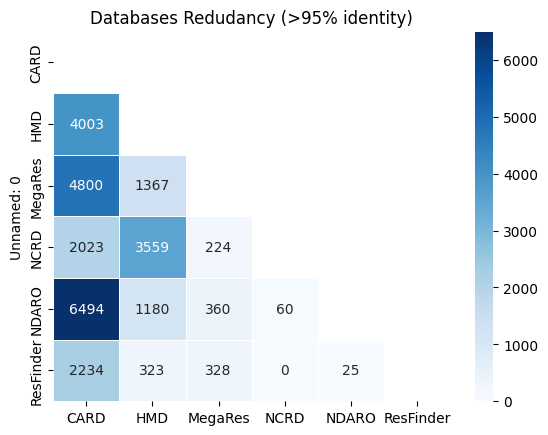

In [19]:
BlastPairWiseAlignmentPivoted = pd.read_csv("../data/processed/BlastPairWiseAlignmentPivoted.cov80.maxseq1.csv", sep="\t")
mask = np.triu(np.ones_like(BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"), dtype=bool)) 
sns.heatmap(
    BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"),
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidth=.5,
    mask=mask,
)
plt.title("Databases Redudancy (>95% identity)")

In [20]:
BlastPairWiseAlignmentPivoted

,Unnamed: 0,CARD,HMD,MegaRes,NCRD,NDARO,ResFinder
0,CARD,26.0,2864.0,1775.0,83.0,1295.0,0.0
1,HMD,4003.0,6884.0,1277.0,1980.0,348.0,6.0
2,MegaRes,4800.0,1367.0,159.0,63.0,286.0,188.0
3,NCRD,2023.0,3559.0,224.0,4945.0,133.0,1.0
4,NDARO,6494.0,1180.0,360.0,60.0,936.0,23.0
5,ResFinder,2234.0,323.0,328.0,0.0,25.0,5.0


Text(0, 0.5, 'Database Size')

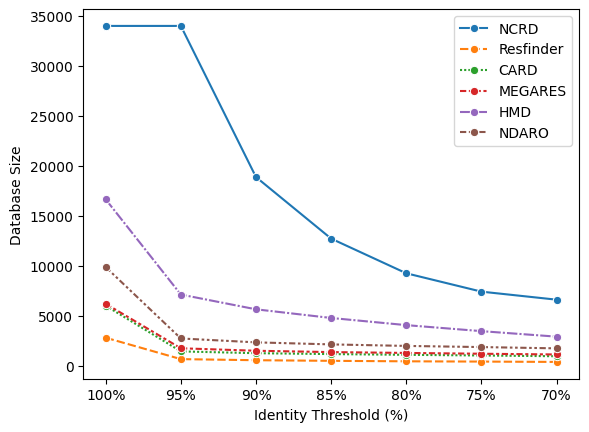

In [21]:
ClustersCdHit = pd.read_csv(
    "../data/processed/cdhitclusters.defaultsettings.csv",
    sep = "\t",
)
sns.lineplot(
    ClustersCdHit.set_index("Unnamed: 0"),
    marker = "o"
)
plt.xlabel("Identity Threshold (%)")
plt.ylabel("Database Size")

In [22]:
ClustersCdHit

,Unnamed: 0,NCRD,Resfinder,CARD,MEGARES,HMD,NDARO
0,100%,34008,2830,6027,6220,16666,9892
1,95%,34008,690,1462,1774,7147,2755
2,90%,18893,580,1283,1527,5670,2366
3,85%,12739,519,1194,1393,4805,2162
4,80%,9273,471,1120,1308,4089,2010
5,75%,7437,444,1053,1228,3487,1895
6,70%,6634,410,978,1155,2937,1766


In [23]:
PairWiseAlignment = pd.read_csv(
    "../data/filtered/AllDatabases.Paiwise.cov80.maxseq1.tsv", 
    sep = "\t",
    skipinitialspace=True, 
    header=None,
    names = "qseqid sseqid pident length qlen slen qstart qend sstart send evalue bitscore ppos full_qseq full_sseq".split(" ")
)
PairWiseAlignment["qcov"] = np.round((PairWiseAlignment["qend"] - PairWiseAlignment["qstart"] + 1) / (PairWiseAlignment["qlen"]) * 100, 2)
PairWiseAlignment["scov"] = np.round((PairWiseAlignment["send"] - PairWiseAlignment["sstart"] + 1) / (PairWiseAlignment["slen"]) * 100, 2)
PairWiseAlignment["qseqtag"] = PairWiseAlignment["qseqid"].str.split("|").str[1]
PairWiseAlignment["sseqtag"] = PairWiseAlignment["sseqid"].str.split("|").str[1]
PairWiseAlignment["qseqid"] = PairWiseAlignment["qseqid"].str.split("|").str[0]
PairWiseAlignment["sseqid"] = PairWiseAlignment["sseqid"].str.split("|").str[0]

In [24]:
PairWiseAlignment

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,evalue,bitscore,ppos,full_qseq,full_sseq,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.0,CARD,MEGARES
1,CARD_1,HMD_829,100.0,286,286,286,1,286,1,286,3.950000e-201,551.0,100.0,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,100.0,100.0,CARD,HMD
2,CARD_2,NCRD_0,100.0,164,164,164,1,164,1,164,3.190000e-117,328.0,100.0,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,100.0,100.0,CARD,NCRD
3,CARD_3,HMD_1374,100.0,291,291,291,1,291,1,291,6.060000e-203,556.0,100.0,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,100.0,100.0,CARD,HMD
4,CARD_4,HMD_247,100.0,270,270,270,1,270,1,270,2.890000e-195,535.0,100.0,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,100.0,100.0,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76568,RESFINDER_2918,CARD_4513,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76569,RESFINDER_2919,CARD_4474,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76570,RESFINDER_2920,CARD_4512,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76571,RESFINDER_2921,CARD_4473,100.0,539,539,539,1,539,1,539,0.000000e+00,1077.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD


<Axes: xlabel='qcov', ylabel='pident'>

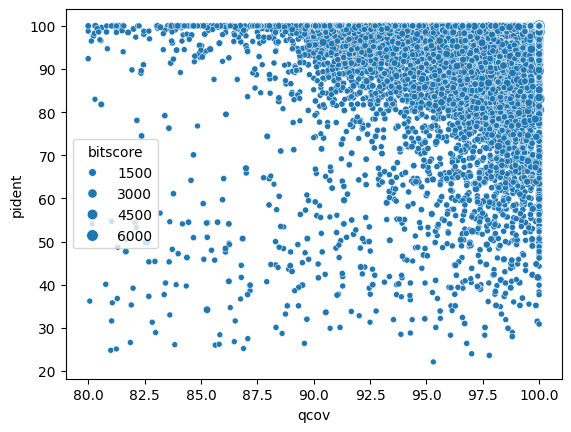

In [25]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="qcov", 
    y="pident",
    size = "bitscore",
    )

<Axes: xlabel='pident', ylabel='ppos'>

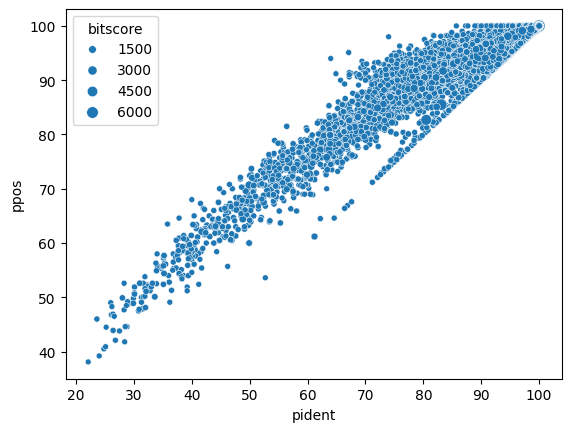

In [26]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="pident", 
    y="ppos",
    size = "bitscore",
    )

In [27]:
PairWiseAlignment

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,evalue,bitscore,ppos,full_qseq,full_sseq,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.0,CARD,MEGARES
1,CARD_1,HMD_829,100.0,286,286,286,1,286,1,286,3.950000e-201,551.0,100.0,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,100.0,100.0,CARD,HMD
2,CARD_2,NCRD_0,100.0,164,164,164,1,164,1,164,3.190000e-117,328.0,100.0,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,100.0,100.0,CARD,NCRD
3,CARD_3,HMD_1374,100.0,291,291,291,1,291,1,291,6.060000e-203,556.0,100.0,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,100.0,100.0,CARD,HMD
4,CARD_4,HMD_247,100.0,270,270,270,1,270,1,270,2.890000e-195,535.0,100.0,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,100.0,100.0,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76568,RESFINDER_2918,CARD_4513,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76569,RESFINDER_2919,CARD_4474,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76570,RESFINDER_2920,CARD_4512,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76571,RESFINDER_2921,CARD_4473,100.0,539,539,539,1,539,1,539,0.000000e+00,1077.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD


In [28]:
with open("../data/processed/MetaDict.cov80.maxseq1.json", "r") as json_file  :
    MetaDict = json.load(json_file)

In [29]:
SequenceSimilarityGraph = nx.from_pandas_edgelist(
    PairWiseAlignment.loc[PairWiseAlignment["pident"] > 80], 
    source="qseqid", 
    target="sseqid", 
    edge_attr=["pident", "bitscore", "evalue","bitscore", "ppos"]
)
nx.set_node_attributes(SequenceSimilarityGraph, MetaDict)
ConnectedComponents = list(nx.connected_components(SequenceSimilarityGraph))
len(ConnectedComponents)

16534

In [30]:
ProblematicComponents = set()
ComponentIndex = dict()
DivergenteAnnotatedClasses = []
for i, component in enumerate(ConnectedComponents):
    ComponentGraph = SequenceSimilarityGraph.subgraph(component)
    Classes = [ComponentGraph.nodes[n].get("Drug Class") for n in component]
    if len(set(Classes)) > 1:
        ComponentIndex[i] = {"status": "problematic", "component": component, "classes": set(Classes), "len": len(component)}
        ProblematicComponents = ProblematicComponents.union(component)
        DivergenteAnnotatedClasses.append(set(Classes))
    else:
        ComponentIndex[i] = {"status": "ok", "component": component, "classes": set(Classes), "len": len(component)}

<Axes: >

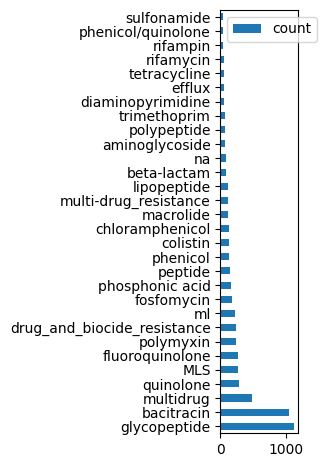

In [31]:
ClassCount = []
for item in pd.Series(DivergenteAnnotatedClasses):
    for c in item:
        ClassCount.append(c)
pd.Series(ClassCount).value_counts().head(30).to_frame().plot(kind = "barh", figsize=(1,5.5))

<Axes: >

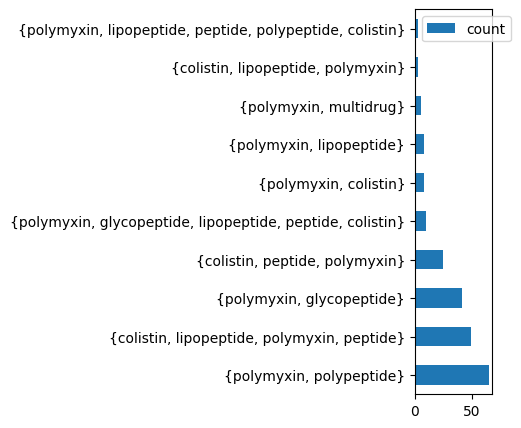

In [32]:
TargetClass = "polymyxin"
pd.Series([c for c in DivergenteAnnotatedClasses if TargetClass in c]).value_counts().head(10).to_frame().plot(kind = "barh", figsize=(1,5))

In [33]:
TargetClass = "polymyxin"
ProblematicCompWithTargetClass = set()
for key, value in ComponentIndex.items():
    if value["status"] == "problematic":
        if TargetClass in value["classes"]:
            ProblematicCompWithTargetClass = ProblematicCompWithTargetClass.union(value["component"])
ProblematicComponentsByClass = SequenceSimilarityGraph.subgraph(ProblematicCompWithTargetClass)
meu_layout = {
    "scalingRatio": 50.0,           # Aumente para afastar os grupos
    "gravity": 0.2,                 # Reduza para não amontoar no centro
    "repulsion": 2,               # Aumente para afastar os nós
    # "outboundAttractionDistribution": True, # Empurra hubs para fora
    # "barnesHutOptimize": True,      # Essencial para seus 70k nós
    # "linLogMode": True              # Melhora a definição de clusters biológicos 
}
Sigma(
    ProblematicComponentsByClass, 
    node_size  = ProblematicComponentsByClass.degree(), 
    node_color =  [ProblematicComponentsByClass.nodes[n].get("Drug Class") for n in ProblematicComponentsByClass.nodes()],
    # node_metrics={"community": "louvain"},

    default_edge_type = "curve",
    layout_settings=meu_layout,
    start_layout=30,
    )

Sigma(nx.Graph with 1,237 nodes and 998 edges)

In [34]:
SelectedCompIndex = None
NodeBait = "HMD_7910"
for key,value in ComponentIndex.items():
    if NodeBait in value["component"]:
        print(key)
        SelectedCompIndex = key
SelectedCluster = SelectedCompIndex
StringFasta = []
for protein in ComponentIndex[SelectedCluster]["component"]:
    print(f">{protein}|{ProblematicComponentsByClass.nodes[protein]['Drug Class']}\n{ProblematicComponentsByClass.nodes[protein]['Sequence']}")
    StringFasta.append(f">{protein}|{ProblematicComponentsByClass.nodes[protein]['Drug Class']}\n{ProblematicComponentsByClass.nodes[protein]['Sequence']}")

1902
>HMD_7614|polymyxin
MFEIHPVKKVSVVIPVYNEQESLPELIRRTTTACESLGKEYEILLIDDGSSDNSAHMLVEASQAENSHIVSILLNRNYGQHSAIMAGFSHVTGDLIITLDADLQNPPEEIPRLVAKADEGYDVVGTVRQNRQDSWFRKTASKMINRLIQRTTGKAMGDYGCMLRAYRRHIVDAMLHSHERSTFIPILANIFARRAIEIPVHHAEREFGESKYSFMRLINLMYDLVTCLTTTPLRMLSLLGSIIAIGGFSIAVLLVILRLTFGPQWAAEGVFMLFAVLFTFIGAQFIGMGLLGEYIGRIYTDVRARPRYFVQQVIRPSSKENE
>HMD_6439|polymyxin
MFEIHPVKKVSVVIPVYNEQESLPELIRRTTTACESLGKEYEILLIDDGSSDNSAHMLVEASQAENSHIVSILLNRNYGQHSAIMAGFSHVTGDLIIILDADLQNPPEEIPRLVAKADEGYDVVGTVRQNRQDSWFRKTASKMINRLIQRTTGKAMGDYGCMLRAYRRHIVDAMLHCHERSTFIPILANIFARRAIEIPVHHAEREFGESKYSFMRLINLMYDLVTCLTTTPLRMLSLLGSIIAIGGFSIAVLLVILRLTFGPQWAAEGVFMLFAVLFTFIGAQFIGMGLLGEYIGRIYTDVRARPRYFVQQVIRPSSKENE
>HMD_6958|polymyxin
MFEIHPVKKVSVVIPVYNEQESLPELIRRTTTACESLGKEYQILLIDDGSSDNSAHMLVEASQAENSHIVSILLNRNYGQHSAIMAGFSHVTGDLIITLDADLQNPPEEIPRLVAKADEGYDVVGTVRQNRQDSWFRKTASKMINRLIQRTTGKAMGDYGCMLRAYRRHIVDAMLHCHERSTFIPILANIFARRAIEIPVHHAEREFGESKYSFMRLINLMYDLVTCLTTTPLRMLSLLGSIIAIGGFSIAVLLVILRLTFGPQWAAEGVFMLFAVLFTFIGAQFIGMG

In [ ]:
ProblematicCompoLenDist = [value["len"] for key, value in ComponentIndex.items() if value["status"] == "problematic"]

In [ ]:
sns.violinplot(ProblematicCompoLenDist)
plt.xlabel("Component Size")
plt.ylabel("Frequency")
plt.title("Distribution of Problematic Component Sizes")

In [ ]:
ProblematicCompoClassDist = [len(value["classes"]) for key, value in ComponentIndex.items() if value["status"] == "problematic"]

In [ ]:
sns.violinplot(ProblematicCompoClassDist)
plt.xlabel("Number of Classes in Component")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Classes in Problematic Component Sizes")

In [ ]:
def ConcateComponentsBy(CompDict, OriginalGraph, Minsize = None, MinClassNumber = None):
    if Minsize is None and MinClassNumber is None:
        raise ValueError("At least one of Minsize or MinClassNumber must be provided. Both cannot be None.")
    elif Minsize is not None and MinClassNumber is not None:
        raise ValueError("Only one of Minsize or MinClassNumber can be provided. Both cannot be set at the same time.")
    
    ConcateComponents = set()
    for key, value in CompDict.items():
        if Minsize is not None and value["len"] >= Minsize and value["status"] == "problematic":
            ConcateComponents = ConcateComponents.union(value["component"])

        elif MinClassNumber is not None and len(value["classes"]) >= MinClassNumber and value["status"] == "problematic":
            ConcateComponents = ConcateComponents.union(value["component"])            
    return OriginalGraph.subgraph(ConcateComponents),ConcateComponents

In [ ]:
# ProblematicSubGraph, ConcateComponents = ConcateComponentsBy(ComponentIndex, SequenceSimilarityGraph, MinClassNumber = 3)
# meu_layout = {
#     "scalingRatio": 50.0,           # Aumente para afastar os grupos
#     "gravity": 0.2,                 # Reduza para não amontoar no centro
#     "repulsion": 2,               # Aumente para afastar os nós
#     # "outboundAttractionDistribution": True, # Empurra hubs para fora
#     # "barnesHutOptimize": True,      # Essencial para seus 70k nós
#     # "linLogMode": True              # Melhora a definição de clusters biológicos 
# }
# Sigma(
#     ProblematicSubGraph, 
#     node_size  = ProblematicSubGraph.degree(), 
#     node_color =  [ProblematicSubGraph.nodes[n].get("Drug Class") for n in ProblematicSubGraph.nodes()],
#     # node_metrics={"community": "louvain"},

#     default_edge_type = "curve",
#     layout_settings=meu_layout,
#     start_layout=30,
#     )

In [ ]:
# ProblematicSubGraph, ConcateComponents = ConcateComponentsBy(ComponentIndex, SequenceSimilarityGraph, Minsize = 10)
# meu_layout = {
#     "scalingRatio": 50.0,           # Aumente para afastar os grupos
#     "gravity": 0.2,                 # Reduza para não amontoar no centro
#     "repulsion": 2,               # Aumente para afastar os nós
#     # "outboundAttractionDistribution": True, # Empurra hubs para fora
#     # "barnesHutOptimize": True,      # Essencial para seus 70k nós
#     # "linLogMode": True              # Melhora a definição de clusters biológicos 
# }
# Sigma(
#     ProblematicSubGraph, 
#     node_size  = ProblematicSubGraph.degree(), 
#     node_color =  [ProblematicSubGraph.nodes[n].get("Drug Class") for n in ProblematicSubGraph.nodes()],
#     # node_metrics={"community": "louvain"},

#     default_edge_type = "curve",
#     layout_settings=meu_layout,
#     start_layout=30,
#     )

In [ ]:
ComponentIndex

In [ ]:
AlignedComponent = Align.ProteinAligner(StringFasta)

In [ ]:
for i, seq in enumerate(AlignedComponent):
    print(f">{seq.id}")
    print(seq.seq)